In [ ]:
from kagglehub import dataset_download
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
import cv2
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import time
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

In [103]:
kaggle_path = dataset_download("datajameson/oxford-17-flowers-dataset")
data_path = os.path.join(kaggle_path, 'Oxford 17 Flowers')

Using Colab cache for faster access to the 'oxford-17-flowers-dataset' dataset.


In [104]:
IMAGE_SIZE = (128, 128)
X = []
y = []

print("Loading images... Please wait.")

for label in os.listdir(data_path):

    dir = os.path.join(data_path, label)

    if not os.path.isdir(dir):
      continue


    for img_name in os.listdir(dir):

        img_path = os.path.join(dir, img_name)

        image = cv2.imread(img_path)

        if image is None:
            print(f"Could not read: {img_path}")
            continue


        image = cv2.resize(image, IMAGE_SIZE)


        hist = cv2.calcHist([image], [0, 1, 2], None, [8, 8, 8], [0, 256, 0, 256, 0, 256])
        cv2.normalize(hist, hist)
        histogram_features = hist.flatten()

        image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        hu_features = cv2.HuMoments(cv2.moments(image_gray)).flatten()
        hu_features = -np.sign(hu_features) * np.log10(np.abs(hu_features) + 1e-10)

        current_features = np.hstack([histogram_features, hu_features])

        X.append(current_features)
        y.append(label)

X = np.array(X)
y = np.array(y)
print(f"Extraction complete! Extracted {X.shape[1]} features per image for {X.shape[0]} images.")

Loading images... Please wait.
Extraction complete! Extracted 519 features per image for 1360 images.


In [105]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [106]:
X_train, X_val, y_train, y_val = train_test_split(X, y_encoded, test_size=0.25, random_state=132, stratify=y_encoded)

In [107]:
models_to_test = {
    'RBF Kernel SVM': {
        'model': SVC(random_state=121),
        'params': {
            'model__C': [0.1, 1.0, 10.0, 100.0],
            'model__gamma': ['scale', 'auto', 0.01, 0.1]
        }
    },
    'Logistic Regression': {
        'model': LogisticRegression(random_state=121, max_iter=2000),
        'params': {
            'model__C': [0.01, 0.1, 1.0, 10.0],
            'model__solver': ['lbfgs', 'liblinear']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=121),
        'params': {
            'model__n_estimators': [100, 200],
            'model__max_depth': [None, 15, 30],
            'model__max_features': ['sqrt', 'log2']
        }
    },
    'Hist Gradient Boosting': {
        'model': HistGradientBoostingClassifier(random_state=121),
        'params': {
            'model__learning_rate': [0.01, 0.1],
            'model__max_iter': [100, 200]
        }
    },
    'k-Nearest Neighbors': {
        'model': KNeighborsClassifier(),
        'params': {
            'model__n_neighbors': [3, 5, 7, 11],
            'model__weights': ['uniform', 'distance']
        }
    }
}

In [108]:
results = []
best_overall_model = None
best_overall_score = 0.0
best_model_name = ""

for name, config in models_to_test.items():
    print(f"Training and tuning {name}...")

    # Standard Scaling works better for SVM, Logistic Regression, and KNN
    model_pipeline = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('model', config['model'])
    ])

    grid_search = GridSearchCV(
        model_pipeline,
        config['params'],
        cv=3,
        scoring='accuracy',
        n_jobs=-1,
        verbose=0
    )

    start_time = time.time()
    grid_search.fit(X_train, y_train)
    end_time = time.time()

    best_model = grid_search.best_estimator_

    # Evaluate on validation set
    test_preds = best_model.predict(X_val)
    test_acc = accuracy_score(y_val, test_preds)

    if test_acc > best_overall_score:
        best_overall_score = test_acc
        best_overall_model = best_model
        best_model_name = name

    results.append({
        'Algorithm': name,
        'Best CV Accuracy': round(grid_search.best_score_, 4),
        'Final Test Accuracy': round(test_acc, 4),
        'Time (seconds)': round(end_time - start_time, 2),
        'Best Hyperparameters': grid_search.best_params_
    })
    print(f"{name} completed in {round(end_time - start_time, 2)}s.")

# Display summary table
results_df = pd.DataFrame(results).sort_values(by='Final Test Accuracy', ascending=False).reset_index(drop=True)

print("\n" + "="*50)
print("FINAL MODEL COMPARISON")
print("="*50)
display(results_df)

Training and tuning RBF Kernel SVM...
RBF Kernel SVM completed in 16.53s.
Training and tuning Logistic Regression...
Logistic Regression completed in 22.0s.
Training and tuning Random Forest...
Random Forest completed in 26.78s.
Training and tuning Hist Gradient Boosting...
Hist Gradient Boosting completed in 621.99s.
Training and tuning k-Nearest Neighbors...
k-Nearest Neighbors completed in 0.67s.

FINAL MODEL COMPARISON


,Algorithm,Best CV Accuracy,Final Test Accuracy,Time (seconds),Best Hyperparameters
0,Random Forest,0.6578,0.6765,26.78,"{'model__max_depth': None, 'model__max_feature..."
1,Hist Gradient Boosting,0.6412,0.6765,621.99,"{'model__learning_rate': 0.1, 'model__max_iter..."
2,RBF Kernel SVM,0.4784,0.4765,16.53,"{'model__C': 10.0, 'model__gamma': 'auto'}"
3,Logistic Regression,0.4971,0.4735,22.00,"{'model__C': 0.1, 'model__solver': 'lbfgs'}"
4,k-Nearest Neighbors,0.3931,0.4118,0.67,"{'model__n_neighbors': 5, 'model__weights': 'd..."


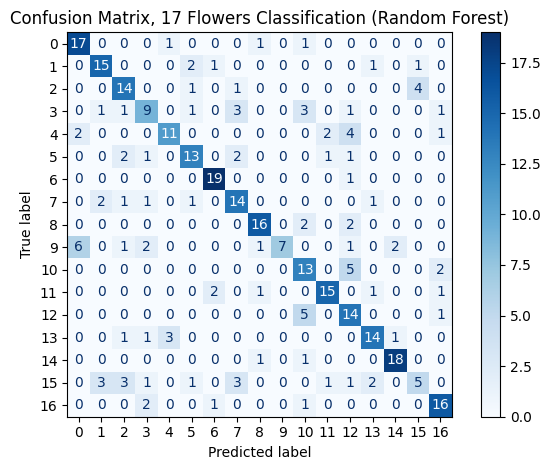

In [109]:
fig, ax = plt.subplots()

ConfusionMatrixDisplay.from_estimator(
    best_overall_model,
    X_val,
    y_val,
    # display_labels=le.classes_,
    cmap='Blues',
    ax=ax
)
plt.title(f"Confusion Matrix, 17 Flowers Classification ({best_model_name})")
plt.tight_layout()
plt.show()